# Chương 1. Tổng quan về Logic mờ và Ứng dụng

## 1.3. Xây dựng tập mờ

### Tiếp cận trực quan

#### Ví dụ: 

Xây dựng tập mờ cho độ hiệu quả của vaccine

**Bối cảnh**

Mô tả **độ hiệu quả của vaccine** chống lại virus SARS-CoV-2. 
Hiệu quả vaccine không phải một giá trị rạch ròi mà mang tính **mờ**, vì nó phụ thuộc:

* loại vaccine,
* độ tuổi người tiêm,
* thời gian sau tiêm,
* và điều kiện dịch tễ.

Vì vậy, ta có thể **xây dựng tập mờ** để mô tả khái niệm “vaccine tốt”, “vaccine trung bình”, “vaccine yếu”.

**Dữ liệu nền**

Theo số liệu WHO công bố:

* Vaccine **Pfizer**: 96%
* Vaccine **Moderna**: 94%
* Vaccine **AstraZeneca**: 63%
* Vaccine **Sinovac**: 51%

**Tập giá trị nền**:
$$
X = \{51, 63, 94\}
$$


**Xây dựng các tập mờ**

| Ký hiệu | Mô tả              | Đặc trưng |
| ------- | ------------------ | --------- |
| **T**   | Vaccine tốt        | quanh 94% |
| **B**   | Vaccine trung bình | quanh 63% |
| **Y**   | Vaccine yếu        | quanh 51% |

* Y: {(50,1), (55,0.8), (63,0)};
* B: {(50,0), (55,0.2), (63,1), (75,0.8), (85,0.3), (94,0)};
* T: {(75,0.3), (85,0.7), (94,1)}.

Tập mờ $Y$ – Vaccine yếu
$$
Y =
\left\{
\dfrac{1}{50},
\dfrac{0.8}{55},
\dfrac{0}{63}
\right\}
$$

Tập mờ $B$ – Vaccine trung bình
$$
B =
\left\{
\dfrac{0}{50},
\dfrac{0.2}{55},
\dfrac{1}{63},
\dfrac{0.8}{75},
\dfrac{0.3}{85},
\dfrac{0}{94}
\right\}
$$

Tập mờ $T$ – Vaccine tốt
$$
T =
\left\{
\dfrac{0.3}{75},
\dfrac{0.7}{85},
\dfrac{1}{94}
\right\}
$$

**Hàm thuộc minh họa**

Giả sử ta chọn các giá trị mờ như sau:

| Hiệu quả (%) | $μ_T(x)$ | $μ_B(x)$ | $μ_Y(x)$ |
| ------------ | ------ | ------ | ------ |
| 50           | 0.0    | 0.0    | 1.0    |
| 55           | 0.0    | 0.2    | 0.8    |
| 63           | 0.0    | 1.0    | 0.0    |
| 75           | 0.3    | 0.8    | 0.0    |
| 85           | 0.7    | 0.3    | 0.0    |
| 94           | 1.0    | 0.0    | 0.0    |

**Công thức hàm thuộc (piecewise-linear)** cho 3 tập mờ “vaccine yếu (Y) – trung bình (B) – tốt (T)” dựa đúng các mốc đã dùng (50, 55, 63, 75, 85, 94).

**1.Vaccine yếu — $μ_Y(x)$**
$$
\mu_Y(x)=
\begin{cases}
1, & x \le 50,\\
1-0.04(x-50), & 50<x\le 55,\\
0.8-0.1(x-55), & 55<x<63,\\
0, & x \ge 63.
\end{cases}
$$

**2.Vaccine trung bình — $μ_B(x)$**

$$
\mu_B(x)=
\begin{cases}
0, & x \le 50,\\
0.04(x-50), & 50<x\le 55,\\
0.2+0.1(x-55), & 55<x\le 63,\\
1-\dfrac{x-63}{60}, & 63<x\le 75,\\
0.8-0.05(x-75), & 75<x\le 85,\\
0.3-\dfrac{x-85}{30}, & 85<x\le 94,\\
0, & x \ge 94.
\end{cases}
$$

**3.Vaccine tốt — $μ_T(x)$**

$$
\mu_T(x)=
\begin{cases}
0, & x \le 75,\\
0.3+0.04(x-75), & 75<x\le 85,\\
0.7+\dfrac{x-85}{30}, & 85<x\le 94,\\
1, & x \ge 94.
\end{cases}
$$

* Ở đây $x$ là **hiệu quả vaccine (%)**.

**Diễn giải**

* Vaccine có hiệu quả **94–96%** → thuộc tập “tốt” với mức độ cao ($μ_T ≈ 1$).
* Vaccine khoảng **60–65%** → “trung bình” ($μ_B ≈ 1$).
* Vaccine khoảng **50–55%** → “yếu” ($μ_Y ≈ 1$).

Tập mờ giúp mô tả rõ hơn các **mức độ hiệu quả vaccine** mà không cần ranh giới cứng (ví dụ: 63% không phải “kém” hoàn toàn mà có thể “trung bình” ở mức μ=1 và “yếu” ở mức μ=0.2).

=> Đây là **ứng dụng thực tế của tiếp cận trực quan** trong xây dựng tập mờ dựa trên **ngữ cảnh** và **tri thức chuyên gia**.



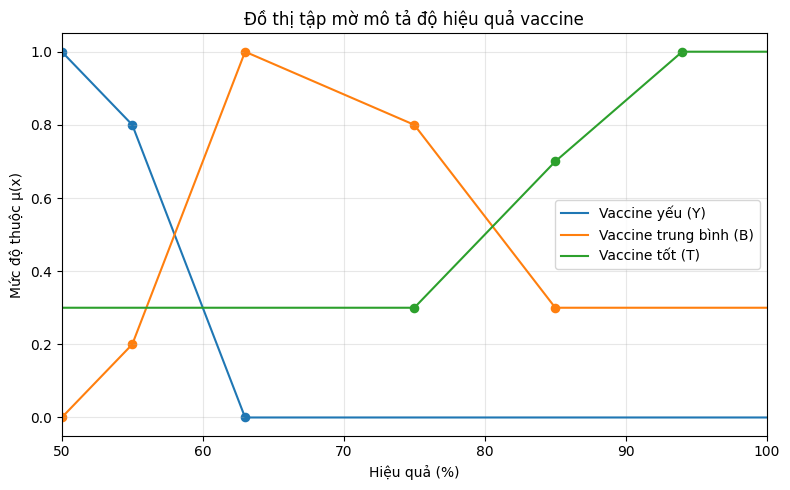

x   |  mu_Y   mu_B   mu_T
---------------------------
 50 |   1.00   0.00   0.30
 55 |   0.80   0.20   0.30
 63 |   0.00   1.00   0.30
 75 |   0.00   0.80   0.30
 85 |   0.00   0.30   0.70
 94 |   0.00   0.30   1.00


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ====== Các điểm mốc (x, mu) cho từng tập mờ ======
# Bạn có thể chỉnh lại mốc tùy ngữ cảnh/nguồn số liệu
anchors_Y = [(50, 1.0), (55, 0.8), (63, 0.0)]          # Vaccine yếu (Y)
anchors_B = [(50, 0.0), (55, 0.2), (63, 1.0), (75, 0.8), (85, 0.3)]# Vaccine trung bình (B)
anchors_T = [(75, 0.3), (85, 0.7), (94, 1.0)]          # Vaccine tốt (T)

def fuzzy_interp(xs, anchors):
    """Nội suy tuyến tính (piecewise linear) qua các điểm neo (x, mu)."""
    anchors = sorted(anchors)                     # đảm bảo theo thứ tự x tăng
    xa, ya = zip(*anchors)
    # ngoại suy: dưới min_x lấy mu ở đầu, trên max_x lấy mu ở cuối
    mu = np.interp(xs, xa, ya, left=ya[0], right=ya[-1])
    return mu

# Trục x: hiệu quả vaccine (%)
x = np.linspace(50, 100, 400)

mu_Y = fuzzy_interp(x, anchors_Y)
mu_B = fuzzy_interp(x, anchors_B)
mu_T = fuzzy_interp(x, anchors_T)

# ====== Vẽ đồ thị ======
plt.figure(figsize=(8, 5))
plt.plot(x, mu_Y, label='Vaccine yếu (Y)')
plt.plot(x, mu_B, label='Vaccine trung bình (B)')
plt.plot(x, mu_T, label='Vaccine tốt (T)')

# vẽ các điểm mốc để minh họa
for (ax, lab) in [(anchors_Y, 'Y'), (anchors_B, 'B'), (anchors_T, 'T')]:
    xa, ya = zip(*ax)
    plt.scatter(xa, ya, s=35)  # đánh dấu mốc

plt.title('Đồ thị tập mờ mô tả độ hiệu quả vaccine')
plt.xlabel('Hiệu quả (%)')
plt.ylabel('Mức độ thuộc μ(x)')
plt.ylim(-0.05, 1.05)
plt.xlim(50, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ====== (Tuỳ chọn) In bảng giá trị tại vài điểm quan trọng ======
samples = [50, 55, 63, 75, 85, 94]
muY_s = fuzzy_interp(np.array(samples), anchors_Y)
muB_s = fuzzy_interp(np.array(samples), anchors_B)
muT_s = fuzzy_interp(np.array(samples), anchors_T)

print("x   |  mu_Y   mu_B   mu_T")
print("---------------------------")
for xi, y, b, t in zip(samples, muY_s, muB_s, muT_s):
    print(f"{xi:>3} |  {y:>5.2f}  {b:>5.2f}  {t:>5.2f}")


### Tiếp cận theo chuyên gia

#### Ví dụ: 

Xây dựng tập mờ **A = “vaccine tốt”** trên nền $X=\left\{51,63,94\right\}$ (% hiệu quả).

**1.Nhiều chuyên gia – lấy trung bình cộng**

Ba chuyên gia $E_1,E_2,E_3$ cho mức độ thuộc $\mu_{A_i}(x)$:

| $x$ (%) | $E_1$ | $E_2$ | $E_3$ |
| ------: | :---: | :---: | :---: |
|      51 |  0.10 |  0.00 |  0.20 |
|      63 |  0.60 |  0.50 |  0.70 |
|      94 |  1.00 |  1.00 |  1.00 |

Tập mờ sử dụng $A$ có
$$
\mu_A(x)=\frac{1}{3}\sum_{i=1}^3 \mu_{A_i}(x).
$$

Tính ra:

* $\mu_A(51)=(0.10+0.00+0.20)/3=0.10$
* $\mu_A(63)=(0.60+0.50+0.70)/3=0.60$
* $\mu_A(94)=(1+1+1)/3=1.00$

**Kết quả:** $A=\left\{\tfrac{0.10}{51},\tfrac{0.60}{63},\tfrac{1.00}{94}\right\}$.

**2.Nhiều chuyên gia – trung bình có trọng số**

Giả sử độ tin cậy $(w_1,w_2,w_3)=(1,2,1)$ (ưu tiên $E_2$).
$$
\mu_A(x)=\frac{\sum_{i=1}^3 w_i,\mu_{A_i}(x)}{\sum_{i=1}^3 w_i}.
$$

Tính ra:

* $\mu_A(51)=\dfrac{1\cdot0.10+2\cdot0.00+1\cdot0.20}{4}=0.075$
* $\mu_A(63)=\dfrac{1\cdot0.60+2\cdot0.50+1\cdot0.70}{4}=0.575$
* $\mu_A(94)=\dfrac{1\cdot1+2\cdot1+1\cdot1}{4}=1.00$

**Kết quả:** $A=\left\{\tfrac{0.075}{51},\tfrac{0.575}{63},\tfrac{1.00}{94}\right\}$.


**3.Chỉ một chuyên gia – dùng ma trận so sánh cặp ($p_{ij}$)**

Chuyên gia đưa **tỷ lệ ưa thích** giữa các phần tử $(x_i, x_j)$ trên $X={51,63,94}$ (đảm bảo các ràng buộc: $p_{ik}=p_{ij}p_{jk}$, $p_{ii}=1$, $p_{ij}=1/p_{ji}$). 

Chuyên gia cho rằng:

* Vaccine hiệu quả 63% tốt hơn loại 51% khoảng 6 lần,
* Vaccine hiệu quả 94% tốt hơn loại 63% khoảng 5/3 ≈ 1.67 lần,
* Suy ra vaccine 94% tốt hơn loại 51% 10 lần (vì $𝑝_{31}=𝑝_{32}p_{21}$).

Ví dụ:
$$
P=(p_{ij})=
\begin{bmatrix}
1 & 6 & 10 \\
\frac{1}{6} & 1 & \frac{5}{3}\\
\frac{1}{10} & \frac{3}{5} & 1
\end{bmatrix}.
$$

Theo công thức:
$$
\mu_i=\mu_A(x_i)=\frac{1}{\sum_{j=1}^{m} p_{ij}},\qquad (m=3).
$$

Tính nhanh **tổng hàng** và $\mu_i$:

* $S_1 = 1 + 6 + 10 = 17$
* $S_2 = 1/6 + 1 + 5/3 = 17/6$
* $S_3 = 1/10 + 3/5 + 1 = 17/10$

$$
\mu=\left\{\frac{1}{17},\frac{6}{17}, \frac{10}{17}\right\}
$$

Chuẩn hóa về ([0,1]) (chia cho giá trị lớn nhất):
$$
\tilde\mu=\left\{\frac{1}{10},\frac{6}{10}, \frac{10}{10}\right\}=\left\{0.10,0.60,1.00\right\}.
$$

**Kết quả:**
$$
A=\left\{\tfrac{0.10}{51},\tfrac{0.60}{63},\tfrac{1.00}{94}\right\}.
$$


### Tiếp cận theo cách suy diễn, diễn giải

#### Ví dụ: Tam giác cân – vuông – đều và các phép and/not

**1.Không gian nền và giả thiết**

* Mỗi tam giác biểu diễn bởi ba góc $t=(a,b,c)$ thỏa $a+b+c=180^\circ$.
* Quy ước sắp xếp $a\ge b\ge c\ge 0$ (nếu đầu vào chưa sắp, ta sắp lại để áp dụng công thức).

**2.Các hàm thuộc cơ sở**

(i) Tam giác cân $T_c$

$$
\mu_c(t)=1-\frac{\min\left\{a-b,b-c\right\}}{60}.
$$

* Nếu $a=b$ **hoặc** $b=c$ thì $\mu_c=1$.
* Chênh lệch lớn nhất có thể lên đến $60^\circ$ ⇒ mẫu số 60.

(ii) Tam giác vuông $T_v$

$$
\mu_v(t)=1-\frac{|a-90|}{90}.
$$

* Nếu có góc $=90^\circ$ (và do đã sắp thứ tự ta kiểm trên $a$) thì $\mu_v=1$.

(iii) Tam giác đều $T_d$

$$
\mu_d(t)=1-\frac{|a-c|}{180}.
$$

* Với tam giác đều $a=b=c=60^\circ$ ⇒ $\mu_d=1$.

**3.Suy diễn tổ hợp (AND/NOT)**

* **Vuông cân**: $T_{vc}=T_v\cap T_c$
  
  $$
  \mu_{vc}(t)=\min\left\{\mu_v(t),\mu_c(t)\right\}.
  $$

* **Tam giác thường** (không vuông, không cân, không đều):
  
  $$
  \mu_t(t)=\min\left\{1-\mu_v(t),1-\mu_c(t),1-\mu_d(t)\right\}.
  $$


# Kết thúc